**Imports**

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn
import GP as gp

%matplotlib widget


In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from cycler import cycler
import seaborn as sns

# Set the color scheme
sns.set_theme()
colors = [
    "#0076C2",
    "#EC6842",
    "#A50034",
    "#009B77",
    "#FFB81C",
    "#E03C31",
    "#6CC24A",
    "#EF60A3",
    "#0C2340",
    "#00B8C8",
    "#6F1D77",
]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

# By default torch uses float32, this can lead to numerical problems for the (semi-)positive definiteness of tensors.
torch.set_default_dtype(torch.float64)

**FEM**

In [ ]:
# File path
file_path = '/mnt/data/bridge_original.geom'

# Step 1: Parse the file to extract nodes and elements
def parse_truss_file(file_path):
    nodes = {}
    elements = []
    
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    # Flag to distinguish between nodes and elements
    parsing_nodes = True
    
    for line in lines:
        parts = line.split()
        if not parts:
            continue
        
        # Switch parsing mode when encountering an empty line
        if len(parts) == 3:
            # Node format: node_id x y
            node_id = int(parts[0])
            x, y = float(parts[1]), float(parts[2])
            nodes[node_id] = (x, y)
            
        elif len(parts) == 4:
            # Element format: element_id node1 node2 area
            element_id = int(parts[0])
            node1, node2 = int(parts[0]), int(parts[1])
            area_idx = int(parts[3])
            elements.append((node1, node2, area_idx))
    
    return nodes, elements


def calculate_total_mass(nodes, elements, rho, area):
    total_volume = 0.0
    
    for element in elements:
        node1, node2, area_idx = element
        x1, y1 = nodes[node1]
        x2, y2 = nodes[node2]

        # Calculate the length of the element
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        # Volume = length * area
        volume = length * area[area_idx]
        total_volume += volume
        total_mass = total_volume * rho
    
    return total_mass


In [4]:
def update_geom_file(geom_path, y_coordinate, update_lines, output_path=None):
    """
    Updates the y-coordinates of upper nodes in the .geom file.
    Args:
        geom_path (str): Path to the existing .geom file.
        y_coordinates (list): New y-coordinates for the upper nodes.
        output_path (str): Path to save the modified .geom file (optional).
    Returns:
        None
    """
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            parts[-1] = str(y_coordinate)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        


    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)

In [5]:
def fem_solver(x):
    # Update y-coordinates in .geom file
    update_lines = [3, 5, 7 ,9, 11, 13, 15, 17, 19]
    update_geom_file('bridge.geom', x, update_lines, output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')
    
    # Update cross-section area
    # props['model']['truss']['area'] = 

    # Run FEM simulation
    globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    frequencies = globdat[gn.EIGENFREQS][0:3] / (2 * np.pi)  # Hz
    
    return weight, frequencies

#weight, frequencies = fem_solver(1)
#print(weight, frequencies)

**Function**

In [6]:
# Calculate the weight of the truss: this later must be replaced by the FEM simulation
def weight_calc(x):
    y = torch.zeros(len(x))
    top = 8
    bottom = 10
    vert = 9
    diag = 10
    area = 1e-4
    rho = 7800

    for i in range(len(x)):
        h = x[i]
        l = top + bottom + h * vert + (1 + h*h)**0.5 * diag
        mass = l * area * rho
        y[i] = mass

    return y

In [7]:
#Define x the possible heights of the truss
X = torch.linspace(2, 4, 10).view(-1, 1)
y = weight_calc(X) #weight of truss

**Initialize GP**

In [8]:
hyperparams = {
    "sig_f": 1,
    "length": 1,
}

hyperparams["noise"] = 0.2
hyperparams["sig_f"] = 1
hyperparams["length"] = 1

GP = gp.GP
cov_func = gp.cov_gaussian

# Compute the posterior mean and covariance
n1 = 10  # Number of points to condition on (observation locations)
n2 = 100 # Number of points in posterior (prediction locations)
n_sample_post = 12  # Number of functions that will be sampled from the posterior
domain_data = [2, 4]
domain = [0, 6]

# Sample observations (X1, t) on the function
torch.manual_seed(seed)
#X1 = torch.rand((n1, 1)) * (domain_data[1] - domain_data[0]) + domain_data[0]
X1 = X
rng = torch.manual_seed(1)
t = y

# Predict points at uniform spacing to capture function
X2 = torch.linspace(domain[0], domain[1], n2).view(-1, 1)

# Compute posterior mean and covariance
mu_pred, cov_pred = GP(X1, t, X2, cov_func, hyperparams)

# Compute the standard deviation at the test points to be plotted
sig = torch.sqrt(torch.diag(cov_pred))

# Draw some samples of the posterior
y2 = torch.tensor(
    np.random.multivariate_normal(
        mean=mu_pred.view(-1),
        cov=cov_pred,
        size=n_sample_post,
    )
)

#kernel = gp.cov_gaussian(X1, X2, **hyperparams)

#gp.GP_logmarglike(x, y, kernel, hyperparams)

**Plot GP**

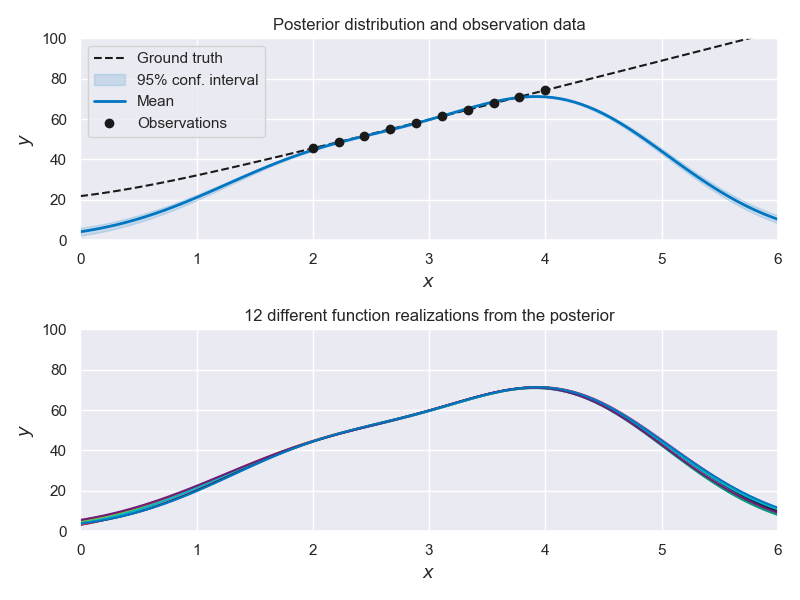

In [9]:
# Plot the postior distribution and some samples
def plot_preds(mu_pred, X1, X2, y2, t):
    mu_pred = mu_pred.flatten()
    X1 = X1.flatten()
    X2 = X2.flatten()
    t = t.flatten()

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

    # Plot the distribution of the function (mean, covariance)
    ax1.plot(X2, weight_calc(X2), "k--", label="Ground truth")
    ax1.fill_between(
        X2.flatten(),
        mu_pred - 1.96 * sig,
        mu_pred + 1.96 * sig,
        color="C0",
        alpha=0.15,
        label="95% conf. interval",
    )
    ax1.plot(X2, mu_pred, "-", color="C0", lw=2, label="Mean")
    ax1.plot(X1, t, "ko", linewidth=2, label="Observations")
    ax1.set_xlabel("$x$", fontsize=13)
    ax1.set_ylabel("$y$", fontsize=13)
    ax1.set_title("Posterior distribution and observation data")
    ax1.axis([domain[0], domain[1], 0, 100])
    ax1.legend(loc="upper left")

    # Plot some samples from this function
    for y_samp in y2:
        ax2.plot(X2, y_samp, "-")
        
    ax2.set_xlabel("$x$", fontsize=13)
    ax2.set_ylabel("$y$", fontsize=13)
    ax2.set_title(f"{n_sample_post} different function realizations from the posterior")
    ax2.axis([domain[0], domain[1], 0, 100])
    ax2.set_xlim([domain[0], domain[1]])
    plt.tight_layout()
    plt.show()


plot_preds(mu_pred, X1, X2, y2, t)

**Optimize GP**

In [10]:
# Initial values
sig_init = 1.0
noise_init = 1.0
length_init = 1.0

# Initialize logsigma, lognoise, and loglengthscale.
logsig = torch.log(torch.tensor([sig_init])).requires_grad_(True)
lognoise = torch.log(torch.tensor([noise_init])).requires_grad_(True)
loglen = torch.log(torch.tensor([length_init])).requires_grad_(True)

# We use the bfgs optimizer.
bfgs = torch.optim.LBFGS((logsig, lognoise, loglen), max_iter=50)

sigmas = []
noises = []
lens = []


# This function is called by the optimizer, it cannot have any arguments, therefore we use the global variables.
def update():
    bfgs.zero_grad()
    hyperparams["sig_f"] = torch.exp(logsig)
    hyperparams["noise"] = torch.exp(lognoise)
    hyperparams["length"] = torch.exp(loglen)

    loss = -gp.GP_logmarglike(X1, t, cov_func, hyperparams)
    loss.backward()
    sigmas.append(torch.exp(logsig).detach()[0].item())
    noises.append(torch.exp(lognoise).detach()[0].item())
    lens.append(torch.exp(loglen).detach()[0].item())
    return loss


# We perform a single step. In this step, multiple iterations of the optimizer are performed.
bfgs.step(update)

print(
    f"BFGS optimal result: sigma_f: {sigmas[-1]}, noise: {noises[-1]}, length scale: {lens[-1]}"
)

BFGS optimal result: sigma_f: 123.37027415283288, noise: 0.0016095384744463379, length scale: 14.740505762791354


c:\Users\stefa\DSAIE\TRUSS_project\truss_bridge\GP.py:85: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3575.)
  logmarglike = -torch.logdet(C)/2 - t.T/2 @ torch.inverse(C) @ t - t.shape[0] * torch.log(torch.tensor(2 * np.pi))/2


C:\Users\stefa\AppData\Local\Temp\ipykernel_23772\2657076279.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  np.random.multivariate_normal(


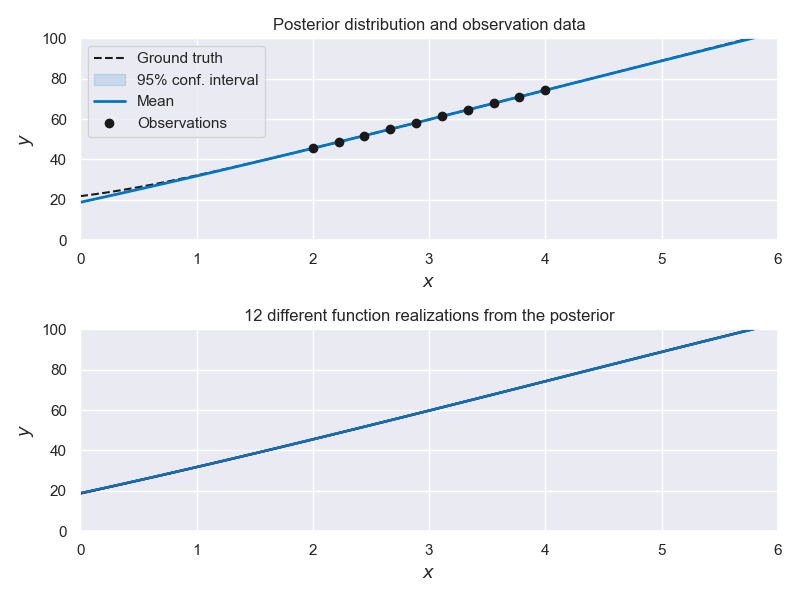

In [11]:
# Compute results
mu_pred, cov_pred = GP(X1, t, X2, cov_func, hyperparams)

# Compute the standard deviation at the test points to be plotted
sig = torch.sqrt(torch.diag(cov_pred))

# Draw some samples of the posterior
y2 = torch.tensor(
    np.random.multivariate_normal(
        mean=mu_pred.view(-1),
        cov=cov_pred.detach() - hyperparams["noise"].detach() ** 2 * torch.eye(cov_pred.shape[0]),
        size=n_sample_post,
    )
)

# Plot
plot_preds(mu_pred, X1, X2, y2, t)